In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
data=pd.read_csv('/content/fiat500.csv')
data.head()

,ID,model,engine_power,age_in_days,km,previous_owners,lat,lon,price
0,1,lounge,51,882,25000,1,44.907242,8.611560,8900
1,2,pop,51,1186,32500,1,45.666359,12.241890,8800
2,3,sport,74,4658,142228,1,45.503300,11.417840,4200
3,4,lounge,51,2739,160000,1,40.633171,17.634609,6000
4,5,pop,73,3074,106880,1,41.903221,12.495650,5700


In [3]:
data.shape

(1520, 9)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1520 entries, 0 to 1519
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               1520 non-null   int64  
 1   model            1520 non-null   object 
 2   engine_power     1520 non-null   int64  
 3   age_in_days      1520 non-null   int64  
 4   km               1520 non-null   int64  
 5   previous_owners  1520 non-null   int64  
 6   lat              1520 non-null   float64
 7   lon              1520 non-null   float64
 8   price            1520 non-null   int64  
dtypes: float64(2), int64(6), object(1)
memory usage: 107.0+ KB


In [5]:
list(data)

['ID',
 'model',
 'engine_power',
 'age_in_days',
 'km',
 'previous_owners',
 'lat',
 'lon',
 'price']

In [6]:
data.isnull()

,ID,model,engine_power,age_in_days,km,previous_owners,lat,lon,price
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
1515,False,False,False,False,False,False,False,False,False
1516,False,False,False,False,False,False,False,False,False
1517,False,False,False,False,False,False,False,False,False
1518,False,False,False,False,False,False,False,False,False


In [7]:
data.isnull().count()

,0
ID,1520
model,1520
engine_power,1520
age_in_days,1520
km,1520
previous_owners,1520
lat,1520
lon,1520
price,1520


In [8]:
(data.isnull().count()/len(data))*100

,0
ID,100.0
model,100.0
engine_power,100.0
age_in_days,100.0
km,100.0
previous_owners,100.0
lat,100.0
lon,100.0
price,100.0


In [9]:
len(data)

1520

In [10]:
data['previous_owners'].unique()

array([1, 2, 3, 4])

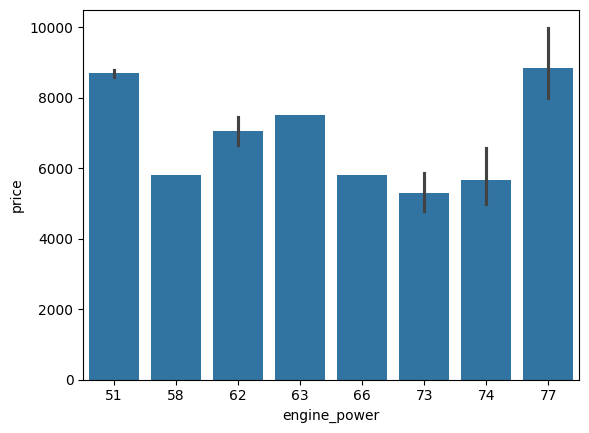

In [11]:
sns.barplot(x='engine_power',y='price',data=data)
plt.show()

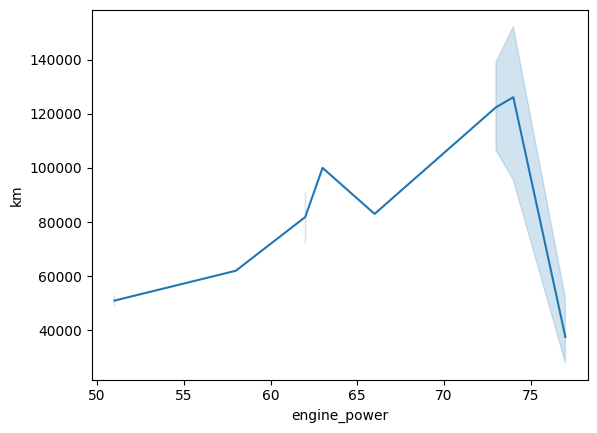

In [12]:
sns.lineplot(x='engine_power',y='km',data=data)
plt.show()

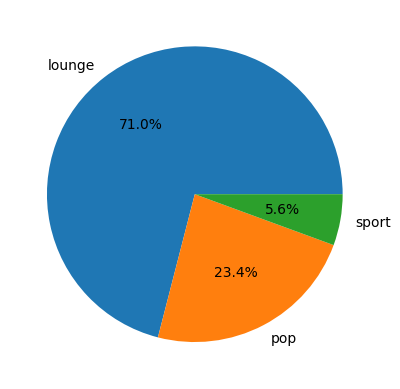

In [13]:
plt.pie(data['model'].value_counts(),
        labels=data['model'].value_counts().index,
        autopct='%1.1f%%')
plt.show()

In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['model'] = le.fit_transform(data['model'])

In [15]:
corr = data.corr()
print(corr)

                       ID     model  engine_power  age_in_days        km  \
ID               1.000000 -0.027744     -0.033980    -0.058918 -0.005935   
model           -0.027744  1.000000      0.190388     0.326649  0.318855   
engine_power    -0.033980  0.190388      1.000000     0.319740  0.285135   
age_in_days     -0.058918  0.326649      0.319740     1.000000  0.835261   
km              -0.005935  0.318855      0.285135     0.835261  1.000000   
previous_owners  0.003170  0.043382     -0.005149     0.072589  0.095087   
lat             -0.064312  0.045418      0.005945     0.064866  0.037562   
lon              0.065560 -0.013037     -0.005850    -0.044418  0.002778   
price            0.027365 -0.349868     -0.277180    -0.893488 -0.860361   

                 previous_owners       lat       lon     price  
ID                      0.003170 -0.064312  0.065560  0.027365  
model                   0.043382  0.045418 -0.013037 -0.349868  
engine_power           -0.005149  0.005945 -

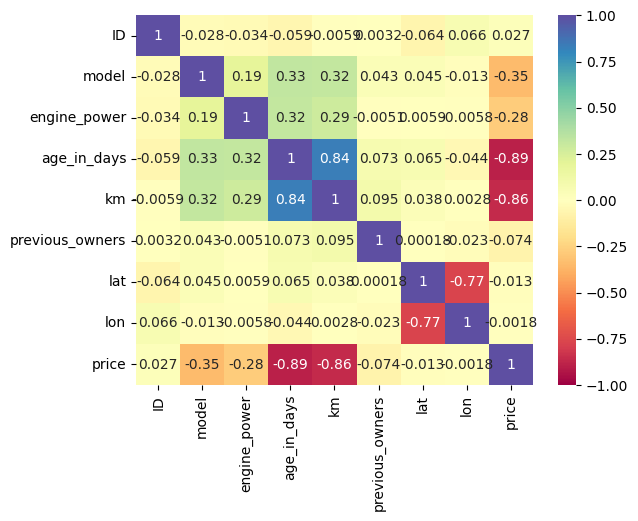

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(corr,vmax=1,vmin=-1,annot=True,cmap='Spectral')
plt.show()

In [17]:
data=data.drop(['ID','lon','lat'],axis=1)

In [18]:
x=data.drop('price',axis=1)
y=data['price']

In [19]:
data.shape

(1520, 6)

In [20]:
x.head()

,model,engine_power,age_in_days,km,previous_owners
0,0,51,882,25000,1
1,1,51,1186,32500,1
2,2,74,4658,142228,1
3,0,51,2739,160000,1
4,1,73,3074,106880,1


In [21]:
y.head()

,price
0,8900
1,8800
2,4200
3,6000
4,5700


In [22]:
from sklearn.model_selection import train_test_split
x_test,x_train,y_test,y_train=train_test_split(data.drop('price',axis=1),data['price'],test_size=0.2,random_state=0)

In [23]:
from sklearn.linear_model import LinearRegression
reg=LinearRegression()
reg.fit(x_train,y_train)

LinearRegression()

In [24]:
ypred=reg.predict(x_test)

In [25]:
ypred

array([ 9826.33775916, 10386.72027865,  7479.59845127, ...,
        7794.87570436, 10029.06085758,  8702.54022479])

In [26]:
from sklearn.metrics import r2_score
r2_score(y_test,ypred)

0.8314007075041459

In [27]:
from sklearn.metrics import mean_absolute_percentage_error as mape
mape_value=mape(y_test,ypred)
mape_value


0.0784896906043264

In [28]:
from sklearn.metrics import mean_squared_error as mse
mse_value=mse(y_test,ypred)
print(mse_value**.5)

789.7960077510417


In [29]:
new = [
    [0, 51, 2197, 25000, 1],
    [1, 51, 3127, 100000, 1],
    [2, 74, 5227, 175000, 1]
]

price = reg.predict(new)

print(price)

[8558.18848075 6304.24984236 3355.61713779]


In [30]:
result=pd.DataFrame(columns=['Actual','Predicted'])
result['Actual']=y_test
result['Predicted']=ypred
result=result.reset_index()
result['id']=result.index
result.head(10)

,index,Actual,Predicted,id
0,1069,9400,9826.337759,0
1,905,10900,10386.720279,1
2,558,9300,7479.598451,2
3,1140,9699,10469.731053,3
4,651,10900,9832.037577,4
5,646,9900,9554.617539,5
6,422,4690,4999.710020,6
7,47,7500,8353.160872,7
8,1461,6500,7323.106066,8
9,1039,6490,7585.292036,9


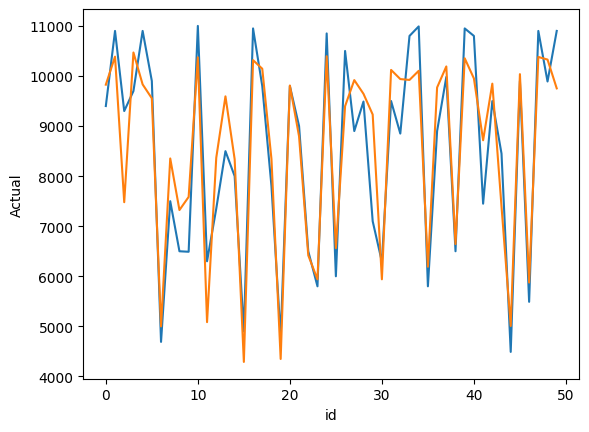

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.lineplot(x='id',y='Actual',data=result.head(50))
sns.lineplot(x='id',y='Predicted',data=result.head(50))
plt.show()